In [1]:
!pip install ftfy regex tqdm -q
!pip install git+https://github.com/openai/CLIP.git -q

print("All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have n

In [2]:
import os                        
import json                      
import random                    
import warnings
warnings.filterwarnings('ignore')

import numpy as np               
import pandas as pd              

from PIL import Image           

import torch                     
import clip                     

from sklearn.metrics.pairwise import cosine_similarity  
from sklearn.cluster import AgglomerativeClustering     
from sklearn.preprocessing import normalize             

import matplotlib.pyplot as plt  
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from collections import Counter, defaultdict

from tqdm import tqdm           

print("All libraries imported!")
print(f"   PyTorch version  : {torch.__version__}")
print(f"   CUDA available   : {torch.cuda.is_available()}")
print(f"   Device           : {'GPU' if torch.cuda.is_available() else 'CPU'}")

All libraries imported!
   PyTorch version  : 2.10.0+cu128
   CUDA available   : True
   Device           : GPU


In [3]:
import glob

csv_matches = glob.glob('/kaggle/input/**/styles.csv', recursive=True)
if not csv_matches:
    csv_matches = glob.glob('/kaggle/input/**/*.csv', recursive=True)

STYLES_CSV = csv_matches[0]
print(f"Styles CSV found : {STYLES_CSV}")

# Find images directory
img_dir_matches = glob.glob('/kaggle/input/**/images', recursive=True)
IMAGES_DIR = img_dir_matches[0] if img_dir_matches else os.path.dirname(STYLES_CSV) + '/images'
print(f"Images directory : {IMAGES_DIR}")

# Load metadata CSV 
df = pd.read_csv(STYLES_CSV, on_bad_lines='skip')
print(f"\nDataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Styles CSV found : /kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv
Images directory : /kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images

Dataset shape: 44,424 rows × 10 columns


In [4]:
#Clean the dataframe
def image_exists(product_id):
    """Return True if the product image file exists on disk."""
    path = os.path.join(IMAGES_DIR, f"{int(product_id)}.jpg")
    return os.path.isfile(path)

print("Checking which images exist on disk... (may take a moment)")
df['image_exists'] = df['id'].apply(image_exists)
df = df[df['image_exists']].reset_index(drop=True)

print(f"\nProducts with images available: {len(df):,}")

def get_image_path(product_id):
    return os.path.join(IMAGES_DIR, f"{int(product_id)}.jpg")

df['image_path'] = df['id'].apply(get_image_path)

Checking which images exist on disk... (may take a moment)

Products with images available: 44,419


In [5]:
# Load CLIP model

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

print("Loading CLIP model... (first run downloads ~350MB)")
model, preprocess = clip.load('ViT-B/32', device=device)
model.eval()  

print("\nCLIP model loaded!")
print(f"Embedding dimension: 512")
print(f"Image input size   : 224×224 pixels")

Using device: cuda
Loading CLIP model... (first run downloads ~350MB)


100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 98.0MiB/s]



CLIP model loaded!
Embedding dimension: 512
Image input size   : 224×224 pixels


In [6]:
# Configuration
MAX_PRODUCTS = 500   # ← Increase this if you have GPU / more time
BATCH_SIZE   = 32   

# Sample products from the dataset
df_sample = df.sample(min(MAX_PRODUCTS, len(df)), random_state=42).reset_index(drop=True)

print(f"Working with {len(df_sample)} products")
print(f"Categories present: {df_sample['articleType'].nunique()}")

Working with 500 products
Categories present: 71


In [7]:
# Generate image embeddings for all products
def generate_image_embeddings(dataframe, model, preprocess, device, batch_size=32):
    """
    Generate CLIP embeddings for all product images in the dataframe.
    
    Process:
    1. Load each image
    2. Resize + normalize it (CLIP's preprocess step)
    3. Pass through CLIP's vision encoder
    4. Get a 512-dimensional vector per image
    5. Normalize vectors to unit length (for cosine similarity)
    
    Returns:
        embeddings : np.ndarray of shape (N, 512)
        valid_indices : list of dataframe row indices with valid images
    """
    all_embeddings = []
    valid_indices  = []
    
    for batch_start in tqdm(range(0, len(dataframe), batch_size),
                            desc='Generating embeddings'):
        
        batch_df = dataframe.iloc[batch_start : batch_start + batch_size]
        batch_images  = []
        batch_indices = []
        
        for idx, row in batch_df.iterrows():
            try:
                img = Image.open(row['image_path']).convert('RGB')
                batch_images.append(preprocess(img))
                batch_indices.append(idx)
            except Exception as e:
                continue
        
        if not batch_images:
            continue
        
        image_tensor = torch.stack(batch_images).to(device)
        
        with torch.no_grad():
            embeddings = model.encode_image(image_tensor)
        
        embeddings = embeddings.cpu().numpy().astype(np.float32)
        
        all_embeddings.append(embeddings)
        valid_indices.extend(batch_indices)
    
    all_embeddings = np.vstack(all_embeddings)
    
    all_embeddings = normalize(all_embeddings, norm='l2')
    
    return all_embeddings, valid_indices

print("Generating CLIP embeddings (this may take a few minutes)...")
embeddings, valid_indices = generate_image_embeddings(
    df_sample, model, preprocess, device, BATCH_SIZE
)

df_valid = df_sample.loc[valid_indices].reset_index(drop=True)

print(f"\nEmbeddings generated!")
print(f"Shape: {embeddings.shape}  →  ({embeddings.shape[0]} products × {embeddings.shape[1]} dimensions)")
print(f"Memory: {embeddings.nbytes / 1024:.1f} KB")

Generating CLIP embeddings (this may take a few minutes)...


Generating embeddings: 100%|██████████| 16/16 [00:05<00:00,  2.72it/s]


Embeddings generated!
Shape: (500, 512)  →  (500 products × 512 dimensions)
Memory: 1000.0 KB


In [8]:
# Complementary Category Map 
COMPLEMENTARY_CATEGORIES = {
    # Footwear → accessories and bottom-wear
    'Shoes'           : ['Socks', 'Casual Shoes', 'Sports Shoes', 'Sandal & Floater', 'Flip Flops'],
    'Sports Shoes'    : ['Socks', 'Track Pants', 'Shorts', 'Casual Shoes'],
    'Casual Shoes'    : ['Socks', 'Jeans', 'Trousers', 'Shorts'],
    'Sandal & Floater': ['Flats', 'Jeans', 'Shorts'],
    'Flip Flops'      : ['Shorts', 'Trousers'],
    'Heels'           : ['Flats', 'Sarees', 'Kurtas'],
    'Flats'           : ['Heels', 'Jeans', 'Kurtas'],
    
    # Tops → bottoms and accessories
    'Shirts'          : ['Jeans', 'Trousers', 'Shorts', 'Ties', 'Belts'],
    'T-Shirts'        : ['Jeans', 'Shorts', 'Track Pants', 'Socks'],
    'Tops'            : ['Jeans', 'Skirts', 'Shorts', 'Leggings'],
    'Kurtas'          : ['Churidar', 'Salwar', 'Leggings', 'Flats'],
    'Sweatshirts'     : ['Track Pants', 'Jeans', 'Sports Shoes'],
    'Jackets'         : ['Shirts', 'Jeans', 'T-Shirts'],
    'Dresses'         : ['Heels', 'Flats', 'Sandal & Floater', 'Jewellery Set'],
    
    # Bottoms → tops and accessories
    'Jeans'           : ['T-Shirts', 'Shirts', 'Casual Shoes', 'Belts'],
    'Trousers'        : ['Shirts', 'Formal Shoes', 'Belts', 'Ties'],
    'Shorts'          : ['T-Shirts', 'Sports Shoes', 'Flip Flops'],
    'Track Pants'     : ['T-Shirts', 'Sports Shoes', 'Sweatshirts'],
    'Skirts'          : ['Tops', 'Heels', 'Flats'],
    
    # Accessories → complementary accessories
    'Watches'         : ['Shirts', 'T-Shirts', 'Wallets'],
    'Sunglasses'      : ['T-Shirts', 'Casual Shoes', 'Caps'],
    'Belts'           : ['Jeans', 'Trousers', 'Shirts'],
    'Wallets'         : ['Watches', 'Belts', 'Bags'],
    'Bags'            : ['Wallets', 'Casual Shoes', 'Shirts'],
    'Socks'           : ['Sports Shoes', 'Casual Shoes', 'Track Pants'],
    'Caps'            : ['T-Shirts', 'Sports Shoes', 'Sunglasses'],
    'Scarves'         : ['Jackets', 'Shirts', 'Trousers'],
}

print(f"Complementarity map loaded with {len(COMPLEMENTARY_CATEGORIES)} category rules.")
print("\nExample rule:")
print("Input category : 'Shirts'")
print(f"Complements   : {COMPLEMENTARY_CATEGORIES['Shirts']}")

Complementarity map loaded with 27 category rules.

Example rule:
Input category : 'Shirts'
Complements   : ['Jeans', 'Trousers', 'Shorts', 'Ties', 'Belts']


In [9]:
# Recommendation Engine 

def get_complementary_recommendations(query_idx, df_valid, embeddings,
                                       category_map, top_k=5):
    """
    Generate complementary product recommendations for a given product.
    
    Algorithm:
    1. Look up the query product's category.
    2. Find the complementary categories from our map.
    3. Filter the catalog to products in those complementary categories.
    4. Rank them by CLIP embedding similarity to the query.
       (Higher similarity = more contextually related, e.g., same style/color family)
    5. Return the top-K most relevant complementary products.
    
    Why CLIP similarity for ranking?
    Even within "Jeans" category (when looking at a Shirt), some jeans will
    visually "go with" the shirt better. CLIP captures style, color, and
    formality — helping us pick the best-matching pair.
    
    Parameters:
    -----------
    query_idx   : int   — row index in df_valid of the query product
    df_valid    : pd.DataFrame — products with metadata
    embeddings  : np.ndarray  — CLIP embeddings (N × 512)
    category_map: dict        — complementary category rules
    top_k       : int         — number of recommendations to return
    
    Returns:
    --------
    recommendations : pd.DataFrame with columns [id, productDisplayName, 
                      articleType, similarity_score]
    """
    query_row = df_valid.iloc[query_idx]
    query_category = query_row.get('articleType', 'Unknown')
    query_embedding = embeddings[query_idx].reshape(1, -1)  # Shape: (1, 512)
    
    # Step 1: Find complementary categories 
    complement_cats = None
    for key in category_map:
        if key.lower() in query_category.lower() or query_category.lower() in key.lower():
            complement_cats = category_map[key]
            break
    
    if complement_cats is None:
        complement_cats = [c for c in df_valid['articleType'].unique()
                           if c != query_category]
    
    # Step 2: Filter catalog to complementary products
    mask = df_valid['articleType'].apply(
        lambda cat: any(comp.lower() in cat.lower() or cat.lower() in comp.lower()
                        for comp in complement_cats)
    )
    mask.iloc[query_idx] = False
    
    candidate_indices = df_valid[mask].index.tolist()
    
    if len(candidate_indices) == 0:
        candidate_indices = [i for i in range(len(df_valid)) if i != query_idx]
    
    # Step 3: Rank by CLIP similarity
    candidate_embeddings = embeddings[candidate_indices]  # Shape: (M, 512)
    similarities = cosine_similarity(query_embedding, candidate_embeddings)[0]
    
    # Sort by similarity (highest first)
    sorted_order = np.argsort(similarities)[::-1][:top_k]
    top_indices  = [candidate_indices[i] for i in sorted_order]
    top_scores   = similarities[sorted_order]
    
    # Step 4: Build result dataframe
    result = df_valid.iloc[top_indices][['id', 'productDisplayName', 'articleType',
                                         'baseColour', 'image_path']].copy()
    result['similarity_score'] = top_scores
    result['match_type'] = 'Complementary'
    
    return result, query_row, complement_cats


print("Recommendation engine defined!")

Recommendation engine defined!



DEMO: Recommendations for a product in category 'Shirts'


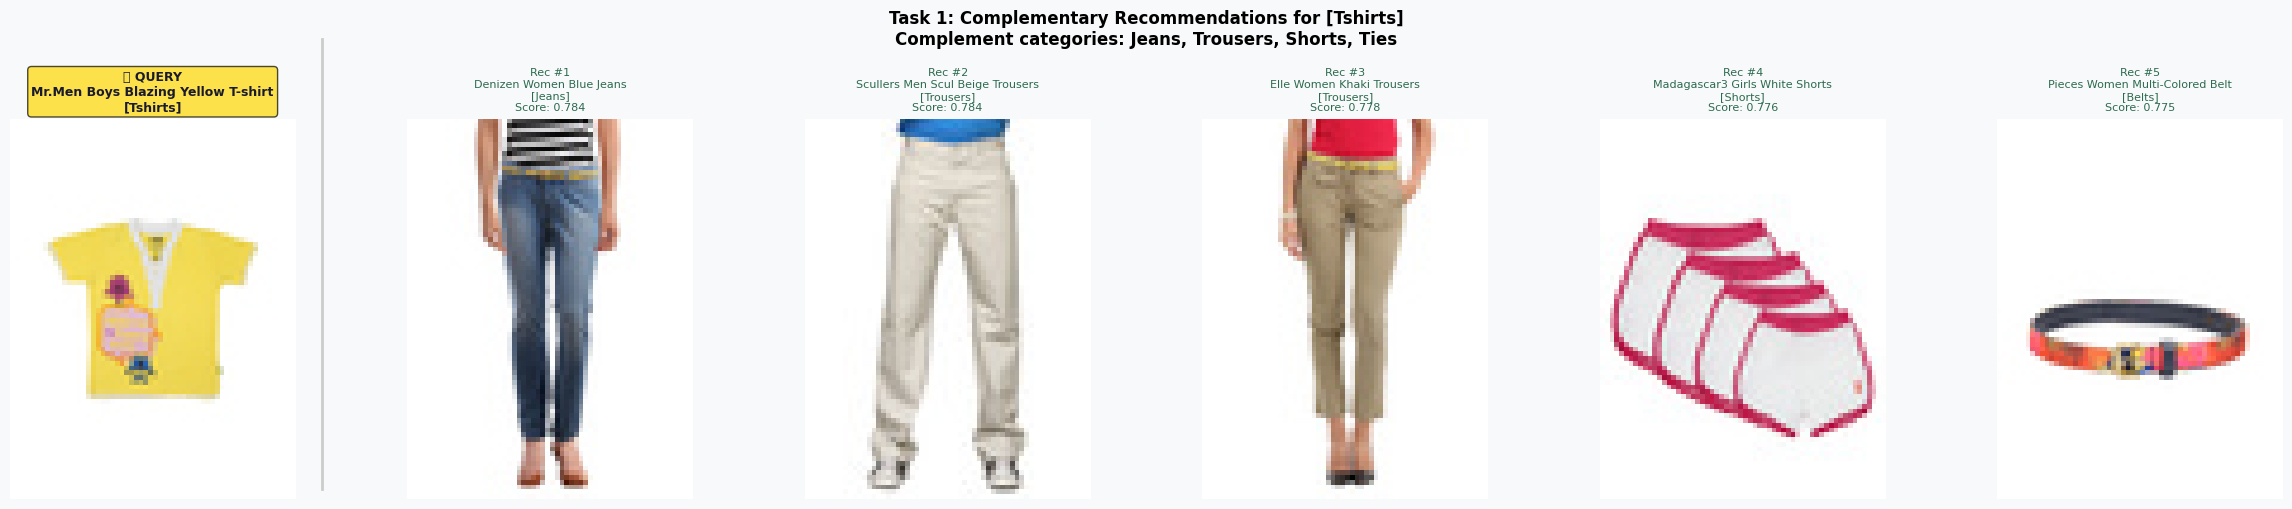

Top Recommendations:
   • Denizen Women Blue Jeans [Jeans] — score: 0.784
   • Scullers Men Scul Beige Trousers [Trousers] — score: 0.784
   • Elle Women Khaki Trousers [Trousers] — score: 0.778
   • Madagascar3 Girls White Shorts [Shorts] — score: 0.776
   • Pieces Women Multi-Colored Belt [Belts] — score: 0.775


In [17]:
#Task 1: Get recommendations for sample products 

def visualize_recommendations(query_idx, df_valid, embeddings, category_map, top_k=5):
    """Show the input product and its complementary recommendations side by side."""
    
    recs, query_row, complement_cats = get_complementary_recommendations(
        query_idx, df_valid, embeddings, category_map, top_k=top_k
    )
    
    n_cols = top_k + 1  
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 5))
    fig.patch.set_facecolor('#F8F9FA')
    
    # ── Plot query product ────────────────────────────────────────────
    ax = axes[0]
    try:
        img = Image.open(query_row['image_path']).convert('RGB')
        ax.imshow(img)
    except:
        ax.text(0.5, 0.5, 'No image', ha='center', va='center')
    
    name = str(query_row.get('productDisplayName', 'Product'))[:35]
    ax.set_title(f'🔍 QUERY\n{name}\n[{query_row["articleType"]}]',
                 fontsize=9, fontweight='bold', color='#1a1a2e',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFD700', alpha=0.7))
    ax.axis('off')
    
    fig.add_artist(plt.Line2D([1/(n_cols) - 0.01, 1/(n_cols) - 0.01], [0.05, 0.95],
                              transform=fig.transFigure, color='#ccc', linewidth=2))
    
    # ── Plot recommendations ──────────────────────────────────────────
    for i, (_, rec_row) in enumerate(recs.iterrows()):
        ax = axes[i + 1]
        try:
            img = Image.open(rec_row['image_path']).convert('RGB')
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, 'No image', ha='center', va='center')
        
        name = str(rec_row.get('productDisplayName', 'Product'))[:35]
        score = rec_row['similarity_score']
        ax.set_title(f'Rec #{i+1}\n{name}\n[{rec_row["articleType"]}]\nScore: {score:.3f}',
                     fontsize=8, color='#2d6a4f')
        ax.axis('off')
    
    fig.suptitle(
        f'Task 1: Complementary Recommendations for [{query_row["articleType"]}]\n'
        f'Complement categories: {", ".join(complement_cats[:4])}',
        fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()
    
    # Print explanation
    
    print("Top Recommendations:")
    for _, r in recs.iterrows():
        print(f"   • {r.get('productDisplayName','?')[:50]} [{r['articleType']}] — score: {r['similarity_score']:.3f}")

demo_categories = ['Shirts', 'T-Shirts', 'Sports Shoes', 'Jeans', 'Watches']

for cat in demo_categories:
    matches = df_valid[df_valid['articleType'].str.contains(cat, case=False, na=False)]
    if len(matches) > 0:
        demo_idx = df_valid.index.get_loc(matches.index[0])
        print(f"\n{'='*60}")
        print(f"DEMO: Recommendations for a product in category '{cat}'")
        print('='*60)
        visualize_recommendations(demo_idx, df_valid, embeddings,
                                   COMPLEMENTARY_CATEGORIES, top_k=5)
        break

In [11]:
# Task 2: Duplicate Detection 

def detect_duplicates_and_create_catalog(df_valid, embeddings, similarity_threshold=0.90):
    """
    Detect duplicate products using CLIP embeddings and agglomerative clustering.
    
    How it works:
    1. Convert similarity threshold to distance: distance = 1 - similarity
       (Agglomerative clustering uses distance, not similarity)
    2. Cluster products where pairwise distance < (1 - threshold)
       = pairwise similarity > threshold
    3. Each cluster = a group of near-duplicate products
    4. One product per cluster is selected as the catalog representative
    
    Parameters:
    -----------
    df_valid             : product dataframe
    embeddings           : CLIP embeddings (N × 512)
    similarity_threshold : float — products above this similarity are "duplicates"
    
    Returns:
    --------
    catalog_df : DataFrame of unique products (one per cluster)
    cluster_labels : array of cluster IDs per product
    """
    n = len(embeddings)
    
    print(f"Running deduplication on {n} products...")
    print(f"Similarity threshold : {similarity_threshold}")
    print(f"Distance threshold   : {1 - similarity_threshold:.2f}")
    
    clustering = AgglomerativeClustering(
        n_clusters=None,                         
        metric='cosine',                         
        linkage='average',                       
        distance_threshold=1 - similarity_threshold 
    )
    cluster_labels = clustering.fit_predict(embeddings)
    
    n_clusters = len(set(cluster_labels))
    n_removed  = n - n_clusters
    reduction  = (n_removed / n) * 100
    
    print(f"\n   Original products    : {n}")
    print(f"   Unique clusters      : {n_clusters}")
    print(f"   Duplicates removed   : {n_removed} ({reduction:.1f}% reduction)")
    
    df_temp = df_valid.copy()
    df_temp['cluster_id'] = cluster_labels
    df_temp['name_length'] = df_temp['productDisplayName'].fillna('').str.len()
    
    catalog_df = (
        df_temp
        .sort_values('name_length', ascending=False) 
        .groupby('cluster_id', sort=False)
        .first()                                       
        .reset_index()
    )
    
    return catalog_df, cluster_labels, df_temp

SIMILARITY_THRESHOLD = 0.90  
catalog_df, cluster_labels, df_clustered = detect_duplicates_and_create_catalog(
    df_valid, embeddings, SIMILARITY_THRESHOLD
)

print("\nDeduplication complete!")

Running deduplication on 500 products...
Similarity threshold : 0.9
Distance threshold   : 0.10

   Original products    : 500
   Unique clusters      : 255
   Duplicates removed   : 245 (49.0% reduction)

Deduplication complete!


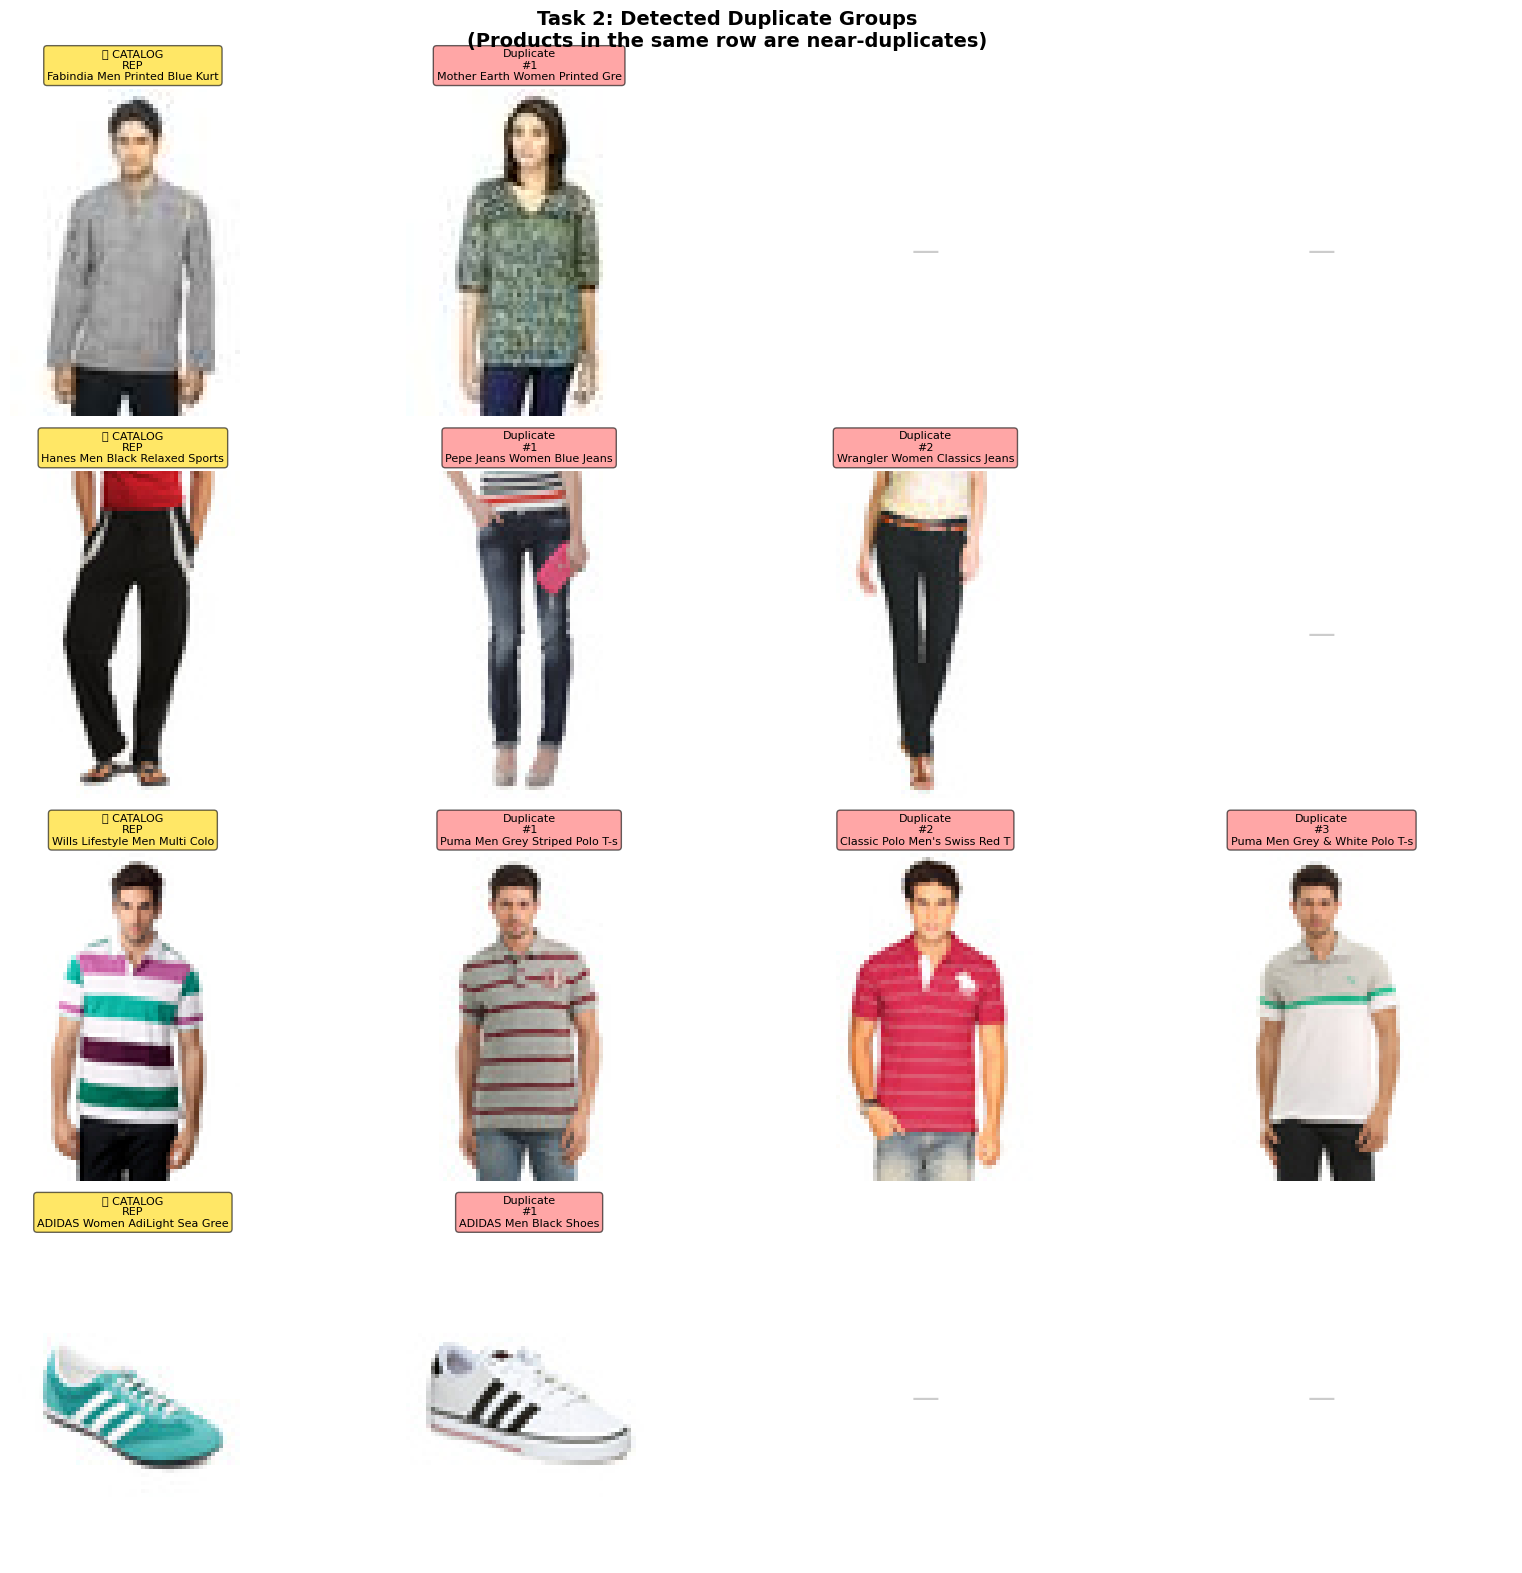


DUPLICATE GROUPS FOUND: 83
Showing top 4 groups above
⭐ = the product kept in the final catalog
🔴 = duplicate (removed from catalog)


In [12]:
# Visualise duplicate groups 
def visualize_duplicate_groups(df_clustered, n_groups=4, max_per_group=4):
    """
    Display groups of duplicate products so we can see what the model detected.
    Each row = one duplicate group. First image in each row = catalog representative.
    """
    cluster_sizes = df_clustered.groupby('cluster_id').size()
    duplicate_clusters = cluster_sizes[cluster_sizes > 1].index.tolist()
    
    if not duplicate_clusters:
        print("No duplicate groups found at this threshold.")
        print("Try lowering the threshold (e.g., 0.80) to find more groups.")
        return
    
    show_clusters = duplicate_clusters[:n_groups]
    
    fig, axes = plt.subplots(len(show_clusters), max_per_group,
                              figsize=(4 * max_per_group, 4 * len(show_clusters)))
    
    if len(show_clusters) == 1:
        axes = [axes]
    
    fig.suptitle('Task 2: Detected Duplicate Groups\n'
                 '(Products in the same row are near-duplicates)',
                 fontsize=14, fontweight='bold')
    
    for row_idx, cluster_id in enumerate(show_clusters):
        group = df_clustered[df_clustered['cluster_id'] == cluster_id].head(max_per_group)
        
        for col_idx in range(max_per_group):
            ax = axes[row_idx][col_idx]
            
            if col_idx < len(group):
                prod = group.iloc[col_idx]
                try:
                    img = Image.open(prod['image_path']).convert('RGB')
                    ax.imshow(img)
                except:
                    ax.text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=12)
                
                name = str(prod.get('productDisplayName','?'))[:30]
                label = '⭐ CATALOG\nREP' if col_idx == 0 else f'Duplicate\n#{col_idx}'
                color = '#FFD700' if col_idx == 0 else '#FF6B6B'
                ax.set_title(f'{label}\n{name}',
                             fontsize=8,
                             bbox=dict(boxstyle='round', facecolor=color, alpha=0.6))
            else:
                ax.text(0.5, 0.5, '—', ha='center', va='center',
                        fontsize=20, color='#ccc')
            
            ax.axis('off')
        
        # Row label
        axes[row_idx][0].set_ylabel(f'Group {row_idx+1}\n(Cluster {cluster_id})',
                                    rotation=0, labelpad=60, fontsize=10,
                                    fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nDUPLICATE GROUPS FOUND: {len(duplicate_clusters)}")
    print(f"Showing top {len(show_clusters)} groups above")
    print(f"⭐ = the product kept in the final catalog")
    print(f"🔴 = duplicate (removed from catalog)")


visualize_duplicate_groups(df_clustered, n_groups=4, max_per_group=4)

In [13]:
# Display the final unique catalog
print("="*60)
print("FINAL UNIQUE PRODUCT CATALOG (first 20 entries)")
print("="*60)

display(catalog_df[['cluster_id', 'id', 'productDisplayName',
                     'articleType', 'baseColour', 'gender']].head(20))

print(f"\nTotal unique products in catalog: {len(catalog_df)}")
print(f"vs original: {len(df_valid)} products")
print(f"Catalog reduction: {len(df_valid) - len(catalog_df)} duplicates removed")
print("\nTask 2 Complete!")

FINAL UNIQUE PRODUCT CATALOG (first 20 entries)


,cluster_id,id,productDisplayName,articleType,baseColour,gender
0,49,50019,Hanes Women Grey Comfortsoft Waistband Cotton ...,Leggings,Grey Melange,Women
1,123,17368,Arrow Men Formal Maroon Tie+Cufflink+Pocket sq...,Accessory Gift Set,Maroon,Men
2,144,57701,Lotus Herbals Papayablem Papaya-N-Saffron Anti...,Face Moisturisers,Cream,Women
3,26,37328,Casio Sheen Women Silver-Toned Dial Chronograp...,Watches,Silver,Women
4,194,15903,Warner Bros Kids Unisex TJ Stud Sandal White C...,Casual Shoes,White,Unisex
5,92,15219,ADIDAS Originals Men Adiracer Remodel Black Ca...,Casual Shoes,Black,Men
6,122,11459,United Colors of Benetton Men Light Winters Bl...,Shirts,Blue,Men
7,177,17796,Chhota Bheem Kids Boy I Like to be Naughty Gre...,Tshirts,Green,Men
8,151,15902,Warner Bros Kids Unisex TJ Cheese Flops Purple...,Flip Flops,Purple,Unisex
9,225,51325,Wildcraft Unisex Black & Grey Checked Bishop S...,Handbags,Black,Unisex



Total unique products in catalog: 255
vs original: 500 products
Catalog reduction: 245 duplicates removed

Task 2 Complete!


In [14]:
# Task 3: Text-to-Image Reverse Product Search
def text_to_image_search(query_text, df_valid, embeddings, model, device, top_k=8):
    """
    Search for products using natural language text.
    
    How it works:
    1. Tokenize the text query (convert words to numbers CLIP understands)
    2. Pass through CLIP's text encoder → get a 512-dim text embedding
    3. Compute cosine similarity between text embedding and ALL image embeddings
    4. Return the top-K most similar images
    
    The key insight: CLIP was trained on (image, text) pairs from the internet,
    so it learned that the image of a blue shirt and the phrase "blue shirt"
    should be close together in embedding space.
    
    Parameters:
    -----------
    query_text  : str  — natural language search query
    df_valid    : pd.DataFrame — product catalog
    embeddings  : np.ndarray — pre-computed image embeddings (N × 512)
    model       : CLIP model
    device      : 'cuda' or 'cpu'
    top_k       : int — number of results to return
    
    Returns:
    --------
    results     : pd.DataFrame with top-K matching products and scores
    text_embed  : np.ndarray — the text embedding (for visualization)
    """
    # Step 1: Encode the text query
    text_tokens = clip.tokenize([query_text]).to(device)
    
    with torch.no_grad():
        text_embedding = model.encode_text(text_tokens)   # Shape: (1, 512)
    
    text_embedding = text_embedding.cpu().numpy().astype(np.float32)
    text_embedding = normalize(text_embedding, norm='l2') # L2 normalize
    
    # Step 2: Compute similarities 
    similarities = cosine_similarity(text_embedding, embeddings)[0]
    
    # Step 3: Rank and return top-K
    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_scores  = similarities[top_indices]
    
    results = df_valid.iloc[top_indices][['id', 'productDisplayName',
                                           'articleType', 'baseColour',
                                           'image_path']].copy()
    results['similarity_score'] = top_scores
    
    return results, text_embedding


print("Reverse search function defined!")

Reverse search function defined!


In [15]:
# Visualisation for reverse search results

def visualize_search_results(query_text, results, n_cols=4):
    """
    Display search results in a clean grid with similarity scores.
    """
    n_results = len(results)
    n_rows = (n_results + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(4 * n_cols, 4.5 * n_rows))
    fig.patch.set_facecolor('#0D1117')
    
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes.tolist()
        axes_flat = axes
    else:
        axes_flat = axes.flatten().tolist()
    
    fig.suptitle(f'Reverse Product Search\nQuery: "{query_text}"',
                 fontsize=14, fontweight='bold', color='white', y=1.01)
    
    for i, (_, row) in enumerate(results.iterrows()):
        ax = axes_flat[i]
        ax.set_facecolor('#1a1a2e')
        
        try:
            img = Image.open(row['image_path']).convert('RGB')
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, 'Image\nnot found', ha='center', va='center',
                    color='white', fontsize=10)
        
        score  = row['similarity_score']
        name   = str(row.get('productDisplayName', 'Product'))[:35]
        color  = str(row.get('baseColour', '?'))
        cat    = str(row.get('articleType', '?'))
        
        # Color-code score: green=high, yellow=medium, red=low
        score_color = '#4CAF50' if score > 0.3 else ('#FFC107' if score > 0.2 else '#F44336')
        
        ax.set_title(
            f'#{i+1} | Score: {score:.3f}\n{name}\n[{cat} • {color}]',
            fontsize=8, color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=score_color, alpha=0.7)
        )
        ax.axis('off')

    for i in range(n_results, len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Print ranked list
    print(f"\nTop {n_results} Results for: \"{query_text}\"")
    print(f"{'Rank':>5} | {'Score':>7} | {'Category':>20} | Product Name")
    print('-' * 70)
    for rank, (_, r) in enumerate(results.iterrows(), 1):
        name = str(r.get('productDisplayName','?'))[:40]
        print(f"{rank:>5} | {r['similarity_score']:>7.4f} | {r['articleType']:>20} | {name}")


print("Visualisation function ready!")

Visualisation function ready!



SEARCHING FOR: "blue casual shirt"


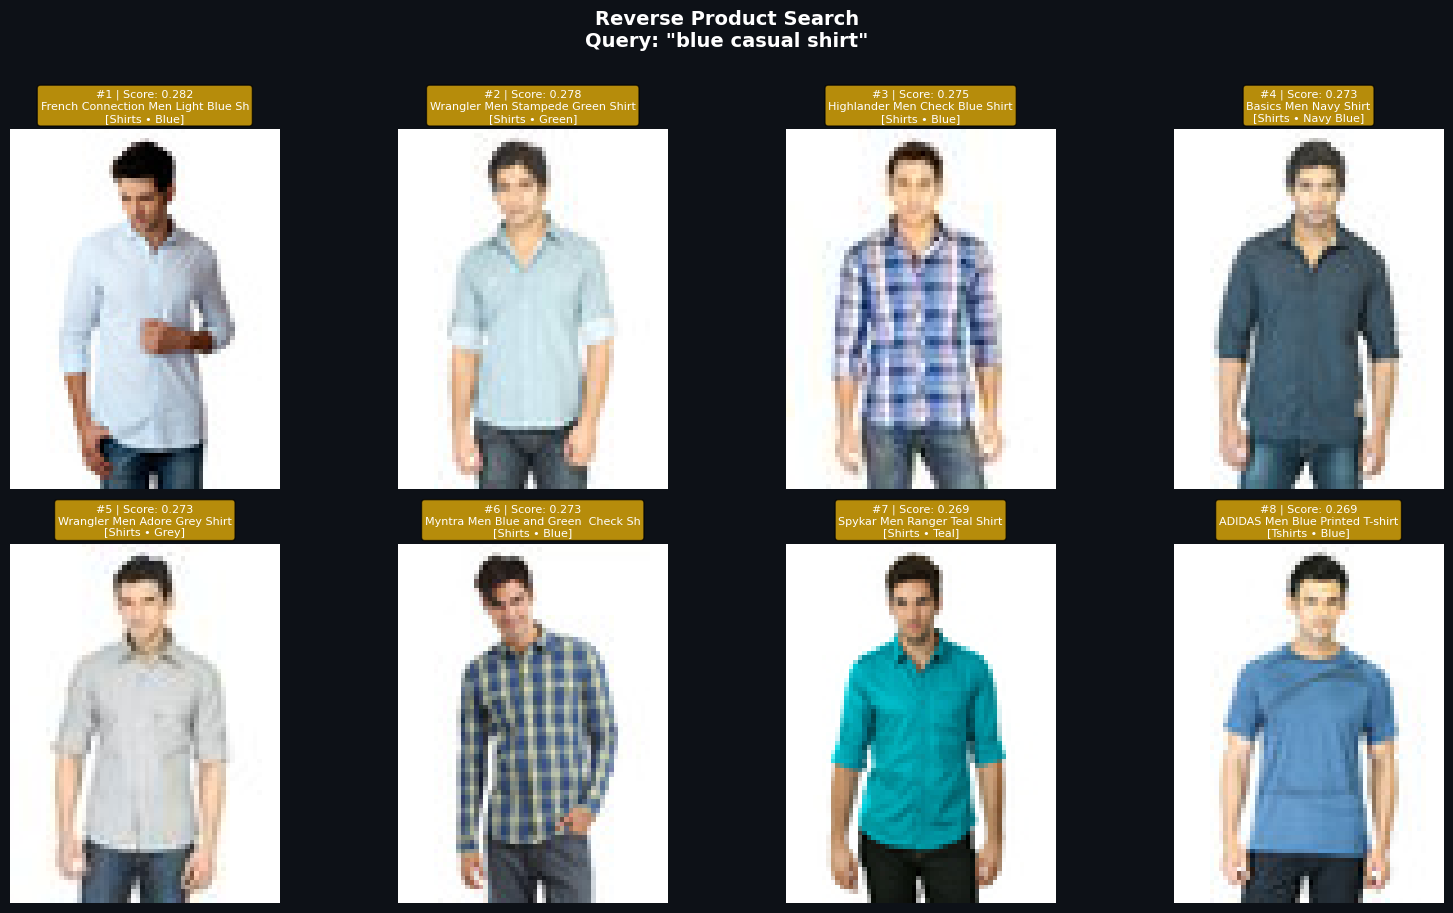


Top 8 Results for: "blue casual shirt"
 Rank |   Score |             Category | Product Name
----------------------------------------------------------------------
    1 |  0.2822 |               Shirts | French Connection Men Light Blue Shirt
    2 |  0.2778 |               Shirts | Wrangler Men Stampede Green Shirt
    3 |  0.2750 |               Shirts | Highlander Men Check Blue Shirt
    4 |  0.2730 |               Shirts | Basics Men Navy Shirt
    5 |  0.2728 |               Shirts | Wrangler Men Adore Grey Shirt
    6 |  0.2727 |               Shirts | Myntra Men Blue and Green  Check Shirt
    7 |  0.2694 |               Shirts | Spykar Men Ranger Teal Shirt
    8 |  0.2692 |              Tshirts | ADIDAS Men Blue Printed T-shirt

SEARCHING FOR: "women's red dress"


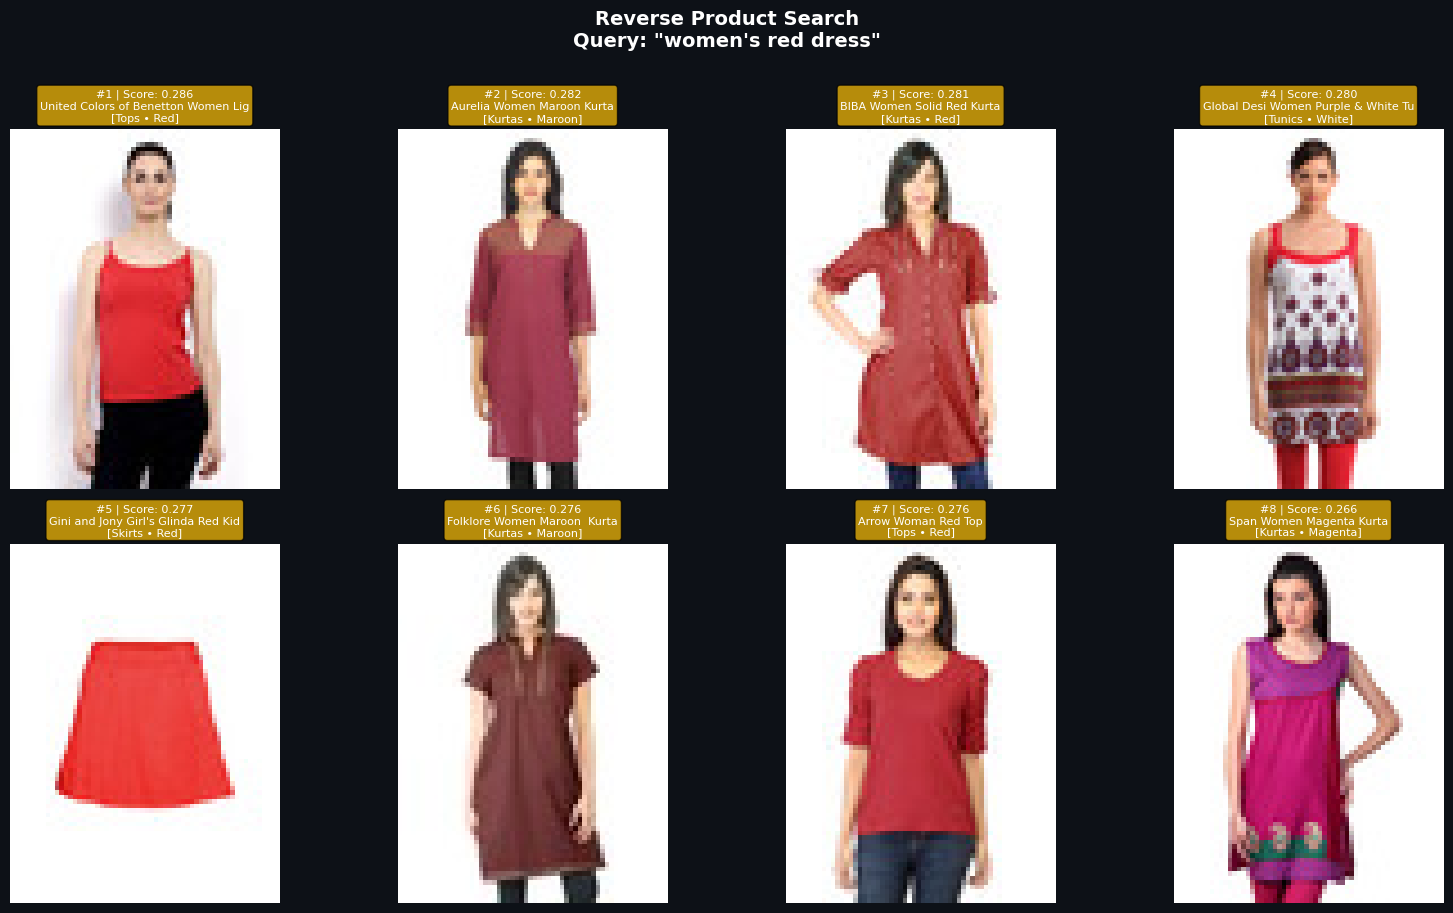


Top 8 Results for: "women's red dress"
 Rank |   Score |             Category | Product Name
----------------------------------------------------------------------
    1 |  0.2862 |                 Tops | United Colors of Benetton Women Light Wi
    2 |  0.2818 |               Kurtas | Aurelia Women Maroon Kurta
    3 |  0.2813 |               Kurtas | BIBA Women Solid Red Kurta
    4 |  0.2801 |               Tunics | Global Desi Women Purple & White Tunic
    5 |  0.2766 |               Skirts | Gini and Jony Girl's Glinda Red Kidswear
    6 |  0.2760 |               Kurtas | Folklore Women Maroon  Kurta
    7 |  0.2757 |                 Tops | Arrow Woman Red Top
    8 |  0.2661 |               Kurtas | Span Women Magenta Kurta

Task 3 Complete!


In [18]:
# Run Reverse Search for Multiple Queries 
search_queries = [
    "blue casual shirt",
    "women's red dress",
]

for query in search_queries:
    print(f"\n{'='*60}")
    print(f"SEARCHING FOR: \"{query}\"")
    print('='*60)
    
    results, _ = text_to_image_search(
        query, df_valid, embeddings, model, device, top_k=8
    )
    visualize_search_results(query, results, n_cols=4)

print("\nTask 3 Complete!")